<a href="https://www.kaggle.com/code/rubyyyovo/pc1-yolo-chest-xrays?scriptVersionId=228194351" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
print("步骤1: 设置YOLOv5环境")

import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import torch
from sklearn.model_selection import train_test_split

# YOLOv5路径
YOLOV5_PATH = '/kaggle/input/yolov5/pytorch/default/3/yolov5-6.0'

if os.path.exists(YOLOV5_PATH):
    print(f"找到上传的YOLOv5文件夹: {YOLOV5_PATH}")
    
    os.makedirs('/kaggle/working/yolov5', exist_ok=True)
    
    important_files = ['requirements.txt', 'train.py', 'detect.py', 'export.py', 'val.py']
    for file in important_files:
        src = os.path.join(YOLOV5_PATH, file)
        dst = os.path.join('/kaggle/working/yolov5', file)
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f"复制文件: {file}")
    
    important_dirs = ['models', 'utils', 'data']
    for dir_name in important_dirs:
        src_dir = os.path.join(YOLOV5_PATH, dir_name)
        dst_dir = os.path.join('/kaggle/working/yolov5', dir_name)
        if os.path.exists(src_dir):
            shutil.copytree(src_dir, dst_dir)
            print(f"复制文件夹: {dir_name}")
    
    %cd /kaggle/working/yolov5
    
    !pip install -r requirements.txt
    
    %cd /kaggle/working
    
else:
    print("未找到上传的YOLOv5文件夹，请确保已正确上传")

步骤1: 设置YOLOv5环境
找到上传的YOLOv5文件夹: /kaggle/input/yolov5/pytorch/default/3/yolov5-6.0
复制文件: requirements.txt
复制文件: train.py
复制文件: detect.py
复制文件: export.py
复制文件: val.py
复制文件夹: models
复制文件夹: utils
复制文件夹: data
/kaggle/working/yolov5
/kaggle/working


In [2]:
INPUT_DIR = '/kaggle/input' 
WORKING_DIR = '/kaggle/working'
OUTPUT_DIR = f'{WORKING_DIR}/NIH_ChestXray_YOLO'

In [3]:
# 第2步：找到所有图像文件
print("步骤2: 查找图像文件")

image_folders = sorted(glob(f'{INPUT_DIR}/*/images_*'))
print(f"找到 {len(image_folders)} 个图像文件夹: {image_folders}")

all_images = []
for folder in image_folders:
    images = glob(f'{folder}/images/*.png')
    all_images.extend(images)
    print(f"在 {os.path.basename(folder)} 中找到 {len(images)} 张图像")

print(f"总共找到 {len(all_images)} 张图像")

image_path_map = {os.path.basename(img): img for img in all_images}

步骤2: 查找图像文件
找到 12 个图像文件夹: ['/kaggle/input/data/images_001', '/kaggle/input/data/images_002', '/kaggle/input/data/images_003', '/kaggle/input/data/images_004', '/kaggle/input/data/images_005', '/kaggle/input/data/images_006', '/kaggle/input/data/images_007', '/kaggle/input/data/images_008', '/kaggle/input/data/images_009', '/kaggle/input/data/images_010', '/kaggle/input/data/images_011', '/kaggle/input/data/images_012']
在 images_001 中找到 4999 张图像
在 images_002 中找到 10000 张图像
在 images_003 中找到 10000 张图像
在 images_004 中找到 10000 张图像
在 images_005 中找到 10000 张图像
在 images_006 中找到 10000 张图像
在 images_007 中找到 10000 张图像
在 images_008 中找到 10000 张图像
在 images_009 中找到 10000 张图像
在 images_010 中找到 10000 张图像
在 images_011 中找到 10000 张图像
在 images_012 中找到 7121 张图像
总共找到 112120 张图像


In [4]:
# 第3步：数据转换函数实现
print("步骤3: 定义数据转换函数")

def extract_disease_classes_from_bbox(bbox_file):
    """从边界框数据中提取实际标注的疾病类别"""
    bbox_df = pd.read_csv(bbox_file)
    unique_diseases = bbox_df['Finding Label'].unique()
    return sorted(list(unique_diseases))

def convert_bbox_to_yolo(image_width, image_height, bbox):
    """
    将[x, y, width, height]格式的边界框转换为YOLOv5格式[x_center, y_center, width, height]
    其中所有值都相对于图像尺寸进行归一化
    """
    x, y, w, h = bbox
    
    # 确保坐标值有效
    if w <= 0 or h <= 0:
        print(f"警告: 无效的边界框宽度或高度: {bbox}")
        w = max(1, w)  # 至少为1像素
        h = max(1, h)  # 至少为1像素
    
    # 计算中心点坐标
    x_center = (x + w/2) / image_width
    y_center = (y + h/2) / image_height
    
    # 归一化宽度和高度
    w_norm = w / image_width
    h_norm = h / image_height
    
    # 确保归一化坐标在[0,1]范围内
    x_center = max(0, min(1, x_center))
    y_center = max(0, min(1, y_center))
    w_norm = max(0, min(1, w_norm))
    h_norm = max(0, min(1, h_norm))
    
    return [x_center, y_center, w_norm, h_norm]

def create_custom_dataset_split(bbox_file, image_path_map, train_ratio, val_ratio, test_ratio, random_seed=42):
    """
    创建自定义数据集划分，确保所有包含边界框的图像都被合理分配
    
    参数:
        bbox_file: 边界框数据文件路径
        image_path_map: 图像名称到路径的映射字典
        train_ratio, val_ratio, test_ratio: 训练、验证、测试集的比例
        random_seed: 随机种子，确保结果可复现
    
    返回:
        train_imgs, val_imgs, test_imgs: 包含图像名称的列表
    """
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split
    
    bbox_df = pd.read_csv(bbox_file)
    
    unique_images = bbox_df['Image Index'].unique()

    available_images = [img for img in unique_images if img in image_path_map]
    print(f"找到 {len(available_images)}/{len(unique_images)} 张有边界框的图像")

    image_label_counts = bbox_df.groupby('Image Index')['Finding Label'].nunique().to_dict()
    
    disease_labels = bbox_df.groupby('Image Index')['Finding Label'].apply(list).to_dict()
    
    # 根据标签数量将图像分组
    label_count_groups = {}
    for img in available_images:
        count = image_label_counts.get(img, 0)
        if count not in label_count_groups:
            label_count_groups[count] = []
        label_count_groups[count].append(img)
    
    # 分割测试集和剩余数据
    np.random.seed(random_seed)
    train_val_imgs, test_imgs = [], []
    
    for count, imgs in label_count_groups.items():
        n_test = max(1, int(len(imgs) * test_ratio))
        test_from_group = np.random.choice(imgs, n_test, replace=False).tolist()
        train_val_from_group = [img for img in imgs if img not in test_from_group]
        
        test_imgs.extend(test_from_group)
        train_val_imgs.extend(train_val_from_group)
    
    # 分割训练集和验证集
    val_ratio_adjusted = val_ratio / (train_ratio + val_ratio)  # 调整验证集比例
    train_imgs, val_imgs = train_test_split(
        train_val_imgs,
        test_size=val_ratio_adjusted,
        random_state=random_seed
    )
    
    print(f"数据集划分: {len(train_imgs)} 训练, {len(val_imgs)} 验证, {len(test_imgs)} 测试")
    
    # 确保每个疾病类别在各个集合中都有代表
    disease_classes = bbox_df['Finding Label'].unique()
    
    for disease in disease_classes:
        # 找出含有此疾病的图像
        disease_images = bbox_df[bbox_df['Finding Label'] == disease]['Image Index'].unique()
        disease_images = [img for img in disease_images if img in image_path_map]
        
        # 检查此疾病是否在各个集合中都有代表
        train_has = any(img in train_imgs for img in disease_images)
        val_has = any(img in val_imgs for img in disease_images)
        test_has = any(img in test_imgs for img in disease_images)
        
        # 如果某个集合中没有此疾病，则从其他集合中移动一个样本
        if not train_has and len(disease_images) > 0:
            for img in disease_images:
                if img in val_imgs:
                    val_imgs.remove(img)
                    train_imgs.append(img)
                    break
                elif img in test_imgs:
                    test_imgs.remove(img)
                    train_imgs.append(img)
                    break
        
        if not val_has and len(disease_images) > 0:
            for img in disease_images:
                if img in train_imgs:
                    train_imgs.remove(img)
                    val_imgs.append(img)
                    break
        
        if not test_has and len(disease_images) > 0:
            for img in disease_images:
                if img in train_imgs and len(train_imgs) > 1:
                    train_imgs.remove(img)
                    test_imgs.append(img)
                    break
    
    print("\n各集合中的疾病分布:")
    for dataset_name, dataset in [("训练集", train_imgs), ("验证集", val_imgs), ("测试集", test_imgs)]:
        dataset_diseases = []
        for img in dataset:
            if img in disease_labels:
                dataset_diseases.extend(disease_labels[img])
        
        disease_counts = {}
        for disease in dataset_diseases:
            if disease in disease_counts:
                disease_counts[disease] += 1
            else:
                disease_counts[disease] = 1
        
        print(f"{dataset_name}: {disease_counts}")
    
    return train_imgs, val_imgs, test_imgs

def convert_data(bbox_file, output_dir, image_path_map, image_width=1024, image_height=1024):
    """
    转换NIH胸部X光数据集为YOLOv5格式，使用自定义的数据集划分
    """
    bbox_df = pd.read_csv(bbox_file)
    
    disease_classes = extract_disease_classes_from_bbox(bbox_file)
    print(f"从BBox_List_2017.csv中提取的疾病类别: {disease_classes}")
    
    class_mapping = {disease: idx for idx, disease in enumerate(disease_classes)}
    
    os.makedirs(os.path.join(output_dir, 'labels'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    
    train_imgs, val_imgs, test_imgs = create_custom_dataset_split(
        bbox_file=bbox_file,
        image_path_map=image_path_map,
        train_ratio=0.6,
        val_ratio=0.2,
        test_ratio=0.2,
        random_seed=42
    )
    
    with open(os.path.join(output_dir, 'data.yaml'), 'w') as f:
        f.write(f"# YOLOv5数据集配置\n")
        f.write(f"path: {output_dir}\n")
        f.write(f"train: images/train\n")
        f.write(f"val: images/val\n")
        f.write(f"test: images/test\n\n")
        f.write(f"# 类别\n")
        f.write(f"nc: {len(disease_classes)}\n")
        f.write(f"names: {disease_classes}\n")
    
    for split, imgs in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        if imgs: 
            os.makedirs(os.path.join(output_dir, 'images', split), exist_ok=True)
            os.makedirs(os.path.join(output_dir, 'labels', split), exist_ok=True)
    
    processed_images = 0
    for img_file in tqdm(train_imgs + val_imgs + test_imgs, desc="处理图像"):
        img_bboxes = bbox_df[bbox_df['Image Index'] == img_file]
        
        if img_file in train_imgs:
            split = 'train'
        elif img_file in val_imgs:
            split = 'val'
        elif img_file in test_imgs:
            split = 'test'
        else:
            continue
        
        label_file = os.path.join(output_dir, 'labels', split, img_file.replace('.png', '.txt'))
        
        with open(label_file, 'w') as f:
            for _, row in img_bboxes.iterrows():
                disease = row['Finding Label']
                if disease in class_mapping:
                    class_id = class_mapping[disease]
                    # 确保边界框数据有效
                    try:
                        bbox = [float(row['Bbox [x']), float(row['y']), float(row['w']), float(row['h]'])]
                        if all(v >= 0 for v in bbox) and bbox[2] > 0 and bbox[3] > 0:  # 有效边界框
                            yolo_bbox = convert_bbox_to_yolo(image_width, image_height, bbox)
                            f.write(f"{class_id} {' '.join([str(x) for x in yolo_bbox])}\n")
                    except (ValueError, TypeError) as e:
                        print(f"跳过无效边界框: {row}, 错误: {e}")
        
        src_img = image_path_map[img_file]
        dst_img = os.path.join(output_dir, 'images', split, img_file)
        
        if os.path.exists(dst_img):
            pass
        else:
            try:
                shutil.copy(src_img, dst_img)
            except shutil.SameFileError:
                print(f"警告: 源文件和目标文件相同 - {src_img}")
        
        processed_images += 1

    print("\n验证图像和标签匹配情况：")
    for split, imgs in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        valid_count = 0
        for img in imgs:
            img_path = os.path.join(output_dir, 'images', split, img)
            label_path = os.path.join(output_dir, 'labels', split, img.replace('.png', '.txt'))
            if os.path.exists(img_path) and os.path.exists(label_path):
                valid_count += 1
        print(f"分割{split}：{valid_count}/{len(imgs)}有效的图像-标签对")

    # 检查空标签文件
    empty_labels = 0
    for split in ['train', 'val', 'test']:
        for label_file in glob(os.path.join(output_dir, 'labels', split, '*.txt')):
            if os.path.getsize(label_file) == 0:
                empty_labels += 1
    print(f"发现{empty_labels}个空标签文件")
    
    print(f"数据集转换完成！处理了 {processed_images} 张图像")
    print(f"训练集大小: {len(train_imgs)}")
    print(f"验证集大小: {len(val_imgs)}")
    print(f"测试集大小: {len(test_imgs)}")
    print(f"目标疾病类别: {disease_classes}")
    
    return disease_classes if processed_images > 0 else []

步骤3: 定义数据转换函数


In [5]:
# 第4步：检查输入数据存在性并转换数据
print("步骤4: 检查输入数据并准备数据集")

# 查找BBox文件
bbox_file_candidates = [
    f'{INPUT_DIR}/BBox_List_2017.csv',
    f'{INPUT_DIR}/data/BBox_List_2017.csv'
]

bbox_file = None
for candidate in bbox_file_candidates:
    if os.path.exists(candidate):
        bbox_file = candidate
        print(f"✓ 找到文件: {bbox_file}")
        break

# 如果没有找到文件，打印错误并显示目录结构
if not bbox_file:
    print("✗ 未找到BBox_List_2017.csv文件")
    print("列出INPUT_DIR下的文件:")
    !ls -la {INPUT_DIR}
    
    # 如果有data子目录，也列出
    if os.path.exists(f'{INPUT_DIR}/data'):
        print("列出INPUT_DIR/data下的文件:")
        !ls -la {INPUT_DIR}/data

# 转换数据
if bbox_file and len(image_path_map) > 0:
    disease_classes = convert_data(
        bbox_file=bbox_file,
        output_dir=OUTPUT_DIR,
        image_path_map=image_path_map,
    )
else:
    print("数据文件缺失，无法继续")
    disease_classes = []

# 数据集结构
if os.path.exists(OUTPUT_DIR) and disease_classes:
    print("\n数据集结构:")
    train_dir = os.path.join(OUTPUT_DIR, 'labels', 'train')
    if os.path.exists(train_dir) and len(os.listdir(train_dir)) > 0:
        !ls -la {train_dir} | head -5
        print("...")
    
    images_train_dir = os.path.join(OUTPUT_DIR, 'images', 'train')
    if os.path.exists(images_train_dir) and len(os.listdir(images_train_dir)) > 0:
        !ls -la {images_train_dir} | head -5
        print("...")
    
    !cat {OUTPUT_DIR}/data.yaml

步骤4: 检查输入数据并准备数据集
✓ 找到文件: /kaggle/input/data/BBox_List_2017.csv
从BBox_List_2017.csv中提取的疾病类别: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']
找到 880/880 张有边界框的图像
数据集划分: 528 训练, 177 验证, 175 测试

各集合中的疾病分布:
训练集: {'Mass': 58, 'Cardiomegaly': 95, 'Pneumothorax': 58, 'Effusion': 88, 'Infiltrate': 70, 'Pneumonia': 74, 'Nodule': 50, 'Atelectasis': 97}
验证集: {'Nodule': 9, 'Atelectasis': 47, 'Cardiomegaly': 30, 'Infiltrate': 27, 'Effusion': 35, 'Pneumothorax': 17, 'Mass': 12, 'Pneumonia': 21}
测试集: {'Nodule': 20, 'Atelectasis': 36, 'Cardiomegaly': 21, 'Effusion': 30, 'Infiltrate': 26, 'Mass': 15, 'Pneumothorax': 23, 'Pneumonia': 25}


处理图像: 100%|██████████| 880/880 [00:09<00:00, 97.30it/s]



验证图像和标签匹配情况：
分割train：528/528有效的图像-标签对
分割val：177/177有效的图像-标签对
分割test：175/175有效的图像-标签对
发现0个空标签文件
数据集转换完成！处理了 880 张图像
训练集大小: 528
验证集大小: 177
测试集大小: 175
目标疾病类别: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']

数据集结构:
total 2136
drwxr-xr-x 2 root root 20480 Mar 18 04:23 .
drwxr-xr-x 5 root root  4096 Mar 18 04:22 ..
-rw-r--r-- 1 root root    80 Mar 18 04:22 00000149_006.txt
-rw-r--r-- 1 root root    81 Mar 18 04:22 00000181_061.txt
ls: write error: Broken pipe
...
total 209548
drwxr-xr-x 2 root root  20480 Mar 18 04:23 .
drwxr-xr-x 5 root root   4096 Mar 18 04:22 ..
-rw-r--r-- 1 root root 383437 Mar 18 04:22 00000149_006.png
-rw-r--r-- 1 root root 356419 Mar 18 04:22 00000181_061.png
ls: write error: Broken pipe
...
# YOLOv5数据集配置
path: /kaggle/working/NIH_ChestXray_YOLO
train: images/train
val: images/val
test: images/test

# 类别
nc: 8
names: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneu

In [6]:
# pc1_generator.py

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import cv2
from tqdm import tqdm
from sklearn.decomposition import PCA
import gc

class PC1Generator:
    def __init__(self, disease_classes, image_path_map, output_dir, device='cuda', 
             bbox_df=None, model_family='replknet', weights_path=None):
        """
        初始化PC1生成器
        
        参数:
            disease_classes: 疾病类别列表
            image_path_map: 图像名称到路径的映射字典
            output_dir: 输出目录
            device: 使用的设备
            bbox_df: 包含边界框数据的DataFrame
            model_family: 模型家族，可以是'replknet'或'convnext'
            weights_path: 预训练权重文件路径
        """
        # 添加CAM路径到sys.path
        import sys
        sys.path.append('/kaggle/input/cam/pytorch/default/2/CAM')
        
        self.disease_classes = disease_classes
        self.device = torch.device(device if torch.cuda.is_available() else "cpu")
        print(f"使用设备: {self.device}")
        self.image_path_map = image_path_map
        self.output_dir = output_dir
        self.model_family = model_family
        
        # 创建疾病名称映射（处理不一致问题）
        self.disease_name_map = {
            'Infiltration': 'Infiltrate',  # Data_Entry_2017中的名称映射到BBox_List_2017中的名称
        }
    
        self.disease_priors = {}
        if bbox_df is not None:
            self.disease_priors = self.initialize_anatomical_priors(bbox_df)
        
        # 初始化模型并加载权重
        self.model = self._init_model(weights_path)
        self.model = self.model.to(self.device)
        self.model.eval()
        
        # 图像预处理
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((384, 384)),  # 使用大一些的输入尺寸，与论文中一致
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        
        # 创建输出目录
        os.makedirs(os.path.join(output_dir, 'pc1_pseudo_labels'), exist_ok=True)
        
    def _init_model(self, weights_path=None):
        """
        初始化模型并加载预训练主干网络权重
        
        参数:
            weights_path: 预训练权重文件路径
        """
        print(f"初始化{self.model_family}模型...")
        
        # 导入必要的模块
        import sys
        sys.path.append('/kaggle/input/cam/pytorch/default/2/CAM')
        
        if self.model_family == 'replknet':
            # 导入RepLKNet模型
            from replknet_func import build_model
            
            # 配置RepLKNet模型
            model_config = {
                "model_name": "RepLKNet-31B",
                "class_n": len(self.disease_classes),  # 使用疾病类别数
                "channels": [128, 256, 512, 1024],
                "input_size": 384,
                "size": 12
            }
            
            # 初始化模型
            model = build_model(model_config)
            
            # 保存特征提取层的引用
            self.feature_layer = model.forward_features
            
            # 加载预训练权重
            if weights_path:
                print(f"加载权重: {weights_path}")
                
                try:
                    # 加载权重到CPU再转移到当前设备
                    state_dict = torch.load(weights_path, map_location=torch.device('cpu'))
                    
                    # 处理权重字典中可能的不同格式
                    if 'model' in state_dict:
                        state_dict = state_dict['model']
                    elif 'state_dict' in state_dict:
                        state_dict = state_dict['state_dict']
                    
                    # 获取模型当前状态字典
                    model_dict = model.state_dict()
                    
                    # 过滤只保留主干网络部分的权重，排除分类头(head)相关权重
                    pretrained_dict = {k: v for k, v in state_dict.items() 
                                      if k in model_dict and 'head' not in k}
                    
                    # 打印加载了多少层
                    print(f'从预训练模型中加载了 {len(pretrained_dict)}/{len(model_dict)} 层权重')
                    
                    # 更新模型字典并加载
                    model_dict.update(pretrained_dict)
                    model.load_state_dict(model_dict, strict=False)
                    print('成功加载主干网络预训练权重')
                    
                    # 随机初始化分类头
                    # 如果head需要特别初始化，可以在这里添加代码
                    print('分类头使用随机初始化')
                    
                except Exception as e:
                    print(f"加载权重时出错: {e}")
                    import traceback
                    traceback.print_exc()
            
            # 将模型包装在DataParallel中
            if torch.cuda.device_count() > 0:
                model = torch.nn.DataParallel(model)
                
            return model
            
        elif self.model_family == 'convnext':
            # ConvNeXt模型的类似实现...
            import timm
            from convnext_func import Net2Head
            
            # 创建ConvNeXt基础模型
            model_name = "convnext_base_384_in22ft1k"
            base_model = timm.create_model(model_name, pretrained=False)
            
            # 修改模型结构
            model_config = {
                "class_n": len(self.disease_classes),
                "unit_n": 1024,
                "size": 12
            }
            
            # 提取主干网络
            base_model = nn.Sequential(*list(base_model.children())[:-2])
            
            # 添加新的分类头
            model = nn.Sequential(base_model, Net2Head(model_config["class_n"], model_config["unit_n"], model_config["size"]))
            
            # 保存特征提取层的引用
            self.feature_layer = base_model
            
            # 加载预训练权重
            if weights_path:
                print(f"加载权重: {weights_path}")
                try:
                    state_dict = torch.load(weights_path, map_location=torch.device('cpu'))
                    
                    # 处理权重字典中可能的不同格式
                    if 'model' in state_dict:
                        state_dict = state_dict['model']
                    elif 'state_dict' in state_dict:
                        state_dict = state_dict['state_dict']
                    
                    # 分离主干网络和分类头的权重
                    base_dict = {}
                    for k, v in state_dict.items():
                        # 检查是否是主干网络的权重
                        if 'fc' not in k and 'head' not in k and 'classifier' not in k:
                            # 可能需要调整键名以匹配您的模型结构
                            base_dict[k] = v
                    
                    # 只加载主干网络部分
                    base_model_dict = base_model.state_dict()
                    # 过滤掉不匹配的键
                    pretrained_dict = {k: v for k, v in base_dict.items() if k in base_model_dict}
                    
                    print(f'从预训练模型中加载了 {len(pretrained_dict)}/{len(base_model_dict)} 层权重')
                    
                    # 更新并加载
                    base_model_dict.update(pretrained_dict)
                    base_model.load_state_dict(base_model_dict, strict=False)
                    print('成功加载主干网络预训练权重')
                    print('分类头使用随机初始化')
                    
                except Exception as e:
                    print(f"加载权重时出错: {e}")
                    import traceback
                    traceback.print_exc()
                    
            return model
            
        elif self.model_family == 'convnext':
            # 导入ConvNeXt模型
            import timm
            from convnext_func import Net2Head
            
            # 创建ConvNeXt基础模型
            model_name = "convnext_base_384_in22ft1k"
            model = timm.create_model(model_name, pretrained=False)
            
            # 修改模型结构
            model_config = {
                "class_n": len(self.disease_classes),
                "unit_n": 1024,
                "size": 12
            }
            
            base_model = nn.Sequential(*list(model.children())[:-2])
            model = nn.Sequential(base_model, Net2Head(model_config["class_n"], model_config["unit_n"], model_config["size"]))
            
            # 保存特征提取层的引用
            self.feature_layer = base_model[-1]
            
            # 加载预训练权重
            if weights_path:
                print(f"加载权重: {weights_path}")
                try:
                    state_dict = torch.load(weights_path, map_location=torch.device('cpu'))
                    
                    # 处理权重字典中可能的不同格式
                    if 'model' in state_dict:
                        state_dict = state_dict['model']
                    elif 'state_dict' in state_dict:
                        state_dict = state_dict['state_dict']
                        
                    model.load_state_dict(state_dict)
                    print('成功加载预训练权重')
                except Exception as e:
                    print(f"加载权重时出错: {e}")
                    import traceback
                    traceback.print_exc()
                    
            return model
    
    def get_feature_maps(self, image_tensor):
        """获取图像的特征图，使用主干网络"""
        # 将image_tensor调整为批次形式并移至设备
        x = image_tensor.unsqueeze(0).to(self.device)
        
        try:
            # 只提取主干网络的特征
            if self.model_family == 'replknet':
                if isinstance(self.model, torch.nn.DataParallel):
                    features = self.model.module.forward_features(x)
                else:
                    features = self.model.forward_features(x)
            elif self.model_family == 'convnext':
                if isinstance(self.model, torch.nn.DataParallel):
                    features = self.model.module[0](x)
                else:
                    features = self.model[0](x)
            
            del x  # 释放 GPU 变量
            torch.cuda.empty_cache()
            return features
        except Exception as e:
            print(f"特征提取时出错: {str(e)}")
            import traceback
            traceback.print_exc()
        return None
    
    def get_pc1_heatmap(self, feature_maps, disease_idx=0):
        """
        使用utils.py中的函数生成PC1热力图
        """
        if feature_maps is None:
            print("警告: 特征图为None，无法生成热力图")
            return None
        
        try:
            # 直接导入utils模块
            from utils import get_heatmap_from_features
            
            # 创建模型配置字典
            model_config = {
                "unit_n": 1024,  # 需要与模型初始化时设置的相同
                "size": 12       # 特征图大小
            }
            
            # 使用utils.py中的函数生成热力图
            heatmap = get_heatmap_from_features("pc1", feature_maps, model_config)
            del feature_maps  # 释放 GPU 变量
            torch.cuda.empty_cache()
            return heatmap
        except Exception as e:
            print(f"生成热力图时出错: {str(e)}")
            import traceback
            traceback.print_exc()
            return None
    
    def pc1_to_bbox(self, pc1_heatmap, min_size_ratio=0.05, max_size_ratio=0.9, edge_threshold=0.05, disease=None):
        """
        将 PC1 热力图转换为边界框，并进行过滤，使用均值作为二值化阈值
        """
        bbox_result = {
            'bbox': None,
            'valid': False,
            'reject_reason': None
        }
    
        img_size = 1024  # 设定标准图像尺寸
        pc1_resized = cv2.resize(pc1_heatmap, (img_size, img_size))  # 调整热力图大小
    
        # **修改：使用均值作为阈值**
        mean_threshold = np.mean(pc1_resized)  # 计算PC1热力图的均值
        heatmap = np.uint8(255 * pc1_resized)  # 归一化到 0-255
        _, thresh = cv2.threshold(heatmap, int(mean_threshold * 255), 255, cv2.THRESH_BINARY)  # 以均值为阈值进行二值化
    
        # 查找连通区域
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
        if not contours:
            bbox_result['reject_reason'] = 'no_contours'
            return bbox_result
    
        # 选取最大连通区域
        max_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(max_contour)
    
        # 过滤不合理的边界框
        min_size = int(img_size * min_size_ratio)
        max_size = int(img_size * max_size_ratio)
        edge_dist = int(img_size * edge_threshold)
    
        if w < min_size or h < min_size:
            bbox_result['reject_reason'] = 'too_small'
            return bbox_result
    
        if w > max_size or h > max_size:
            bbox_result['reject_reason'] = 'too_large'
            return bbox_result
    
        # 过滤过度靠近边界的边界框
        is_edge_box = (x < edge_dist or y < edge_dist or (x + w) > (img_size - edge_dist) or (y + h) > (img_size - edge_dist))
        if is_edge_box and (w * h) / (img_size * img_size) > 0.5:
            bbox_result['reject_reason'] = 'edge_box_too_large'
            return bbox_result
    
        # 过滤极端宽高比的边界框
        aspect_ratio = max(w / h, h / w)
        if aspect_ratio > 5:
            bbox_result['reject_reason'] = 'extreme_aspect_ratio'
            return bbox_result
    
        bbox_result['bbox'] = [x, y, w, h]
        bbox_result['valid'] = True
        return bbox_result

    
    def initialize_anatomical_priors(self, bbox_df):
        """
        从已标注的数据中学习疾病的解剖学分布
        
        参数:
            bbox_df: BBox_List_2017 DataFrame
        
        返回:
            disease_priors: 包含每种疾病边界框统计信息的字典
        """
        print("从已标注数据初始化解剖学先验知识...")
        
        # 初始化字典来存储每种疾病的统计信息
        disease_priors = {}
        
        # 图像尺寸
        img_size = 1024
        
        # 按疾病分组处理边界框
        for disease in self.disease_classes:
            # 获取该疾病的所有边界框
            disease_boxes = bbox_df[bbox_df['Finding Label'] == disease]
            
            if len(disease_boxes) < 5:  # 如果样本太少，跳过
                print(f"  警告: 疾病 '{disease}' 的标注样本数量不足 ({len(disease_boxes)}), 跳过学习")
                continue
                
            # 初始化存储边界框特征的列表
            centers_x = []
            centers_y = []
            widths = []
            heights = []
            areas = []
            aspect_ratios = []
            
            # 计算每个边界框的特征
            for _, row in disease_boxes.iterrows():
                x = float(row['Bbox [x'])
                y = float(row['y'])
                w = float(row['w'])
                h = float(row['h]'])
                
                # 归一化坐标(相对于图像大小)
                x_norm = x / img_size
                y_norm = y / img_size
                w_norm = w / img_size
                h_norm = h / img_size
                
                # 计算中心点
                center_x = x_norm + w_norm/2
                center_y = y_norm + h_norm/2
                
                centers_x.append(center_x)
                centers_y.append(center_y)
                widths.append(w_norm)
                heights.append(h_norm)
                areas.append(w_norm * h_norm)
                aspect_ratios.append(max(w_norm/h_norm, h_norm/w_norm))
            
            # 计算统计信息
            disease_priors[disease] = {
                # 位置统计
                'center_x': {
                    'mean': np.mean(centers_x),
                    'std': np.std(centers_x),
                    'min': np.min(centers_x),
                    'max': np.max(centers_x),
                    'values': centers_x  # 保存所有值用于分布分析
                },
                'center_y': {
                    'mean': np.mean(centers_y),
                    'std': np.std(centers_y),
                    'min': np.min(centers_y),
                    'max': np.max(centers_y),
                    'values': centers_y
                },
                # 尺寸统计
                'width': {
                    'mean': np.mean(widths),
                    'std': np.std(widths),
                    'min': np.min(widths),
                    'max': np.max(widths)
                },
                'height': {
                    'mean': np.mean(heights),
                    'std': np.std(heights),
                    'min': np.min(heights),
                    'max': np.max(heights)
                },
                'area': {
                    'mean': np.mean(areas),
                    'std': np.std(areas),
                    'min': np.min(areas),
                    'max': np.max(areas)
                },
                'aspect_ratio': {
                    'mean': np.mean(aspect_ratios),
                    'std': np.std(aspect_ratios),
                    'min': np.min(aspect_ratios),
                    'max': np.max(aspect_ratios)
                },
                'sample_count': len(disease_boxes)
            }
            # 清理临时列表
            del centers_x, centers_y, widths, heights, areas, aspect_ratios
            print(f"  已学习疾病 '{disease}' 的分布 (样本数: {len(disease_boxes)})")
        
        return disease_priors

    def validate_bbox_with_anatomical_knowledge(self, bbox, disease, confidence_level=2):
        """
        根据从已标注数据学习到的解剖学分布验证边界框
        
        参数:
            bbox: [x, y, w, h] 边界框
            disease: 疾病名称
            confidence_level: 置信度水平，用于设定有效范围(标准差的倍数)
            
        返回:
            result: 字典，包含验证结果和拒绝原因(如果被拒绝)
        """
        result = {'valid': True, 'reject_reason': None}
        
        # 如果没有这种疾病的先验知识或样本太少，返回True
        if disease not in self.disease_priors or self.disease_priors[disease]['sample_count'] < 5:
            return result
        
        # 图像尺寸
        img_size = 1024
        
        # 提取边界框信息
        x, y, w, h = bbox
        
        # 归一化坐标
        x_norm = x / img_size
        y_norm = y / img_size
        w_norm = w / img_size
        h_norm = h / img_size
        
        # 计算特征
        center_x = x_norm + w_norm/2
        center_y = y_norm + h_norm/2
        area = w_norm * h_norm
        aspect_ratio = max(w_norm/h_norm, h_norm/w_norm)
        
        # 获取先验
        prior = self.disease_priors[disease]
        
        # 检查中心点X坐标
        x_mean = prior['center_x']['mean']
        x_std = prior['center_x']['std']
        x_min = x_mean - confidence_level * x_std
        x_max = x_mean + confidence_level * x_std
        
        if center_x < x_min or center_x > x_max:
            result['valid'] = False
            result['reject_reason'] = 'center_x_out_of_range'
            return result
        
        # 检查中心点Y坐标
        y_mean = prior['center_y']['mean']
        y_std = prior['center_y']['std']
        y_min = y_mean - confidence_level * y_std
        y_max = y_mean + confidence_level * y_std
        
        if center_y < y_min or center_y > y_max:
            result['valid'] = False
            result['reject_reason'] = 'center_y_out_of_range'
            return result
        
        # 检查面积
        area_mean = prior['area']['mean']
        area_std = prior['area']['std']
        area_min = max(0.001, area_mean - confidence_level * area_std)  # 确保最小面积大于0
        area_max = min(0.9, area_mean + confidence_level * area_std)    # 确保最大面积不超过90%
        
        if area < area_min:
            result['valid'] = False
            result['reject_reason'] = 'area_too_small'
            return result
        
        if area > area_max:
            result['valid'] = False
            result['reject_reason'] = 'area_too_large'
            return result
        
        # 检查宽高比
        ar_mean = prior['aspect_ratio']['mean']
        ar_std = prior['aspect_ratio']['std']
        ar_max = ar_mean + confidence_level * ar_std
        
        if aspect_ratio > ar_max:
            result['valid'] = False
            result['reject_reason'] = 'extreme_aspect_ratio'
            return result
        
        return result
    
    def process_unlabeled_images(self, unlabeled_data_df, max_per_class=200, visualization=True):
        """
        处理未标注的图像并生成PC1伪标签，适配不同的模型架构
        
        参数:
            unlabeled_data_df: 包含未标注图像信息的DataFrame
            max_per_class: 每个类别最多处理的图像数
            threshold: PC1阈值
            visualization: 是否生成可视化结果
        
        返回:
            pseudo_labels: 包含伪标签信息的DataFrame
        """
        # 创建存储伪标签的DataFrame
        pseudo_labels = pd.DataFrame(columns=['Image Index', 'Finding Label', 'Bbox [x', 'y', 'w', 'h]'])
    
        saved_accepted = {disease: 0 for disease in self.disease_classes}
        saved_rejected = {disease: 0 for disease in self.disease_classes}
        
        # 创建可视化目录
        if visualization:
            vis_dir = os.path.join(self.output_dir, 'pc1_visualization')
            os.makedirs(vis_dir, exist_ok=True)
            
            # 创建子目录用于保存被拒绝的边界框可视化
            rejected_vis_dir = os.path.join(vis_dir, 'rejected')
            os.makedirs(rejected_vis_dir, exist_ok=True)
            
            # 创建子目录按拒绝原因分类
            for reason in ['too_small', 'too_large', 'edge_box_too_large', 'extreme_aspect_ratio', 
                          'anatomically_unlikely', 'processing_error', 'no_contours']:
                os.makedirs(os.path.join(rejected_vis_dir, reason), exist_ok=True)
        
        # 统计信息
        total_processed = 0
        total_accepted = 0
        total_rejected = 0
        rejection_reasons = {}
        
        # 创建字典，用于记录每种疾病的标签统计
        disease_stats = {disease: {'processed': 0, 'accepted': 0, 'rejected': 0, 
                                 'reject_reasons': {}} for disease in self.disease_classes}
        
        # 按类别处理图像
        for disease_idx, disease in enumerate(self.disease_classes):
            print(f"处理疾病: {disease}")
            
            # 映射疾病名称（处理不一致性）
            data_entry_disease = disease
            for k, v in self.disease_name_map.items():
                if v == disease:
                    data_entry_disease = k
            
            # 选择包含当前疾病但没有边界框的图像
            disease_images = unlabeled_data_df[unlabeled_data_df['Finding Labels'].str.contains(data_entry_disease)]
            
            if len(disease_images) > max_per_class:
                disease_images = disease_images.sample(max_per_class, random_state=42)
            
            print(f"  选择了 {len(disease_images)} 张 {data_entry_disease} 的图像")
            
            for _, row in tqdm(disease_images.iterrows(), total=len(disease_images)):
                img_file = row['Image Index']
                disease_stats[disease]['processed'] += 1
                total_processed += 1
                
                # 检查图像是否存在
                if img_file not in self.image_path_map:
                    continue
                
                img_path = self.image_path_map[img_file]
                
                try:
                    # 读取图像
                    img = cv2.imread(img_path)
                    if img is None:
                        print(f"无法读取图像: {img_path}")
                        continue
                        
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    
                    # 预处理图像
                    input_tensor = self.transform(img)
                    
                    # 使用当前疾病索引提取特征图
                    # 在调用函数前复制utils.py中的get_feature_maps函数
                    from utils import get_feature_maps
                    feature_maps = get_feature_maps(self.model_family, input_tensor.unsqueeze(0).to(self.device), 
                                                   disease_idx, self.model)
                    
                    if feature_maps is None:
                        print(f"无法为图像 {img_file} 提取特征")
                        continue
                    model_config = {
                        "unit_n": 1024,  # 需要与模型初始化时设置的相同
                        "size": 12       # 特征图大小
                    }
                    # 使用utils.py中的函数生成热力图
                    from utils import get_heatmap_from_features
                    pc1_heatmap = get_heatmap_from_features("pc1", feature_maps, model_config)
                    # 立即释放feature_maps内存
                    del feature_maps
                    torch.cuda.empty_cache()
                    if pc1_heatmap is None:
                        print(f"无法为图像 {img_file} 生成热力图")
                        continue
                    
                    # 转换为边界框
                    bbox_result = self.pc1_to_bbox(
                        pc1_heatmap, 
                        min_size_ratio=0.05,
                        max_size_ratio=0.9,
                        edge_threshold=0.05,
                        disease=disease  # 传入疾病类型用于解剖学验证
                    )
                    
                    # 处理结果并进行统计
                    if bbox_result['valid'] and bbox_result['bbox'] is not None:
                        # 添加到伪标签
                        x, y, w, h = bbox_result['bbox']
                        new_row = pd.DataFrame({
                            'Image Index': [img_file],
                            'Finding Label': [disease],
                            'Bbox [x': [float(x)],
                            'y': [float(y)],
                            'w': [float(w)],
                            'h]': [float(h)]
                        })
                        pseudo_labels = pd.concat([pseudo_labels, new_row], ignore_index=True)
                        total_accepted += 1
                        disease_stats[disease]['accepted'] += 1
                    else:
                        total_rejected += 1
                        disease_stats[disease]['rejected'] += 1
                        reject_reason = bbox_result['reject_reason']
                        if reject_reason not in rejection_reasons:
                            rejection_reasons[reject_reason] = 0
                        rejection_reasons[reject_reason] += 1
                        
                        if reject_reason not in disease_stats[disease]['reject_reasons']:
                            disease_stats[disease]['reject_reasons'][reject_reason] = 0
                        disease_stats[disease]['reject_reasons'][reject_reason] += 1
                    
                    # 可视化处理
                    if visualization:
                        # 绘制原始图像和PC1热力图
                        plt.figure(figsize=(15, 5))
                        
                        # 原始图像
                        plt.subplot(1, 3, 1)
                        plt.imshow(img)
                        plt.title('Original Image')
                        plt.axis('off')
                        
                        # PC1热力图
                        plt.subplot(1, 3, 2)
                        plt.imshow(img)
                        plt.imshow(cv2.resize(pc1_heatmap, (img.shape[1], img.shape[0])), 
                                  alpha=0.5, cmap='jet')
                        plt.title(f'PC1 Heatmap ({self.model_family})')
                        plt.axis('off')
                        
                        # 边界框可视化
                        plt.subplot(1, 3, 3)
                        plt.imshow(img)
                        
                        # 根据边界框结果选择保存路径
                        if bbox_result['valid'] and bbox_result['bbox'] is not None:
                            x, y, w, h = bbox_result['bbox']
                            # 绘制边界框
                            rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='green', linewidth=2)
                            plt.gca().add_patch(rect)
                            plt.title('Accepted Bounding Box')
                            
                            # 仅保存前5张被接受的图像
                            if saved_accepted[disease] < 5:
                                save_path = os.path.join(vis_dir, f"{img_file.replace('.png', '')}_{self.model_family}_accepted.png")
                                saved_accepted[disease] += 1
                            else:
                                save_path = None
                        else:
                            plt.title(f'Rejected: {bbox_result["reject_reason"]}')
                            
                            # 仅保存前5张被拒绝的图像
                            if saved_rejected[disease] < 5:
                                reason_dir = os.path.join(rejected_vis_dir, 
                                                        bbox_result["reject_reason"] if bbox_result["reject_reason"] else 'unknown')
                                os.makedirs(reason_dir, exist_ok=True)
                                save_path = os.path.join(reason_dir, f"{img_file.replace('.png', '')}_{self.model_family}_rejected.png")
                                saved_rejected[disease] += 1
                            else:
                                save_path = None
                        
                        # 添加图像信息
                        plt.suptitle(f"Image: {img_file} - Disease: {disease} - Model: {self.model_family}", fontsize=14)
                        plt.tight_layout()
                        
                        if save_path:
                            plt.savefig(save_path)
                            plt.close('all')
                        plt.close()
                    
                except Exception as e:
                    print(f"处理图像 {img_file} 时出错: {e}")
                    if 'processing_error' not in rejection_reasons:
                        rejection_reasons['processing_error'] = 0
                    rejection_reasons['processing_error'] += 1
                    
                    if 'processing_error' not in disease_stats[disease]['reject_reasons']:
                        disease_stats[disease]['reject_reasons']['processing_error'] = 0
                    disease_stats[disease]['reject_reasons']['processing_error'] += 1

        # **改用更安全的方式释放内存**
        feature_maps = None
        pc1_heatmap = None
        input_tensor = None
        torch.cuda.empty_cache()
        gc.collect()
        
        # 增强的统计信息输出
        print(f"\n=== {self.model_family} PC1伪标签生成详细统计 ===")
        print(f"总处理图像数: {total_processed}")
        print(f"接受的边界框数: {total_accepted} ({total_accepted/total_processed*100:.1f}% 的处理图像)")
        print(f"拒绝的边界框数: {total_rejected} ({total_rejected/total_processed*100:.1f}% 的处理图像)")
        
        print("\n拒绝原因统计:")
        for reason, count in sorted(rejection_reasons.items(), key=lambda x: x[1], reverse=True):
            print(f"  - {reason}: {count} ({count/total_rejected*100:.1f}% 的拒绝案例)")
        
        print("\n按疾病类别的统计:")
        for disease, stats in disease_stats.items():
            if stats['processed'] > 0:
                accept_rate = stats['accepted'] / stats['processed'] * 100
                print(f"\n  {disease}: 处理={stats['processed']}, 接受={stats['accepted']} ({accept_rate:.1f}%), 拒绝={stats['rejected']}")
                if stats['rejected'] > 0:
                    print("    拒绝原因:")
                    for reason, count in sorted(stats['reject_reasons'].items(), key=lambda x: x[1], reverse=True):
                        print(f"      - {reason}: {count} ({count/stats['rejected']*100:.1f}%)")
        
        # 保存伪标签到CSV
        pseudo_labels_path = os.path.join(self.output_dir, 'pc1_pseudo_labels', f'{self.model_family}_pseudo_labels.csv')
        pseudo_labels.to_csv(pseudo_labels_path, index=False)
        
        return pseudo_labels
    
    def merge_with_original_labels(self, original_bbox_df, pseudo_labels_df):
        """
        将伪标签与原始标签合并
        
        参数:
            original_bbox_df: 原始边界框DataFrame
            pseudo_labels_df: 伪标签DataFrame
            
        返回:
            merged_df: 合并后的DataFrame
        """
        # 合并数据
        merged_df = pd.concat([original_bbox_df, pseudo_labels_df], ignore_index=True)
        
        # 检查并处理重复项
        merged_df = merged_df.drop_duplicates(subset=['Image Index', 'Finding Label'], keep='first')
        
        # 保存合并后的数据
        merged_path = os.path.join(self.output_dir, 'pc1_pseudo_labels', 'merged_labels.csv')
        merged_df.to_csv(merged_path, index=False)
        
        print(f"合并后的标签总数: {len(merged_df)}")
        print(f"  - 原始标签: {len(original_bbox_df)}")
        print(f"  - 伪标签: {len(pseudo_labels_df)}")
        print(f"  - 合并去重后: {len(merged_df)}")
        
        return merged_df

    def analyze_pseudo_labels_quality(self, pseudo_labels_df, original_bbox_df=None):
        """分析生成的伪标签质量"""
        # 检查各疾病分布
        disease_counts = pseudo_labels_df['Finding Label'].value_counts()
        print("伪标签疾病分布:")
        for disease, count in disease_counts.items():
            print(f"  - {disease}: {count}")
        
        # 分析边界框尺寸统计
        bbox_areas = []
        aspect_ratios = []
        
        for _, row in pseudo_labels_df.iterrows():
            w = float(row['w'])
            h = float(row['h]'])
            area = w * h
            aspect = max(w/h, h/w)
            bbox_areas.append(area)
            aspect_ratios.append(aspect)
        
        print("\n边界框统计:")
        print(f"  - 平均面积: {np.mean(bbox_areas):.1f} px²")
        print(f"  - 中位面积: {np.median(bbox_areas):.1f} px²")
        print(f"  - 平均宽高比: {np.mean(aspect_ratios):.2f}")
        
        # 如果有原始标签，计算统计差异
        if original_bbox_df is not None:
            orig_areas = []
            orig_aspects = []
            
            for _, row in original_bbox_df.iterrows():
                w = float(row['w'])
                h = float(row['h]'])
                area = w * h
                aspect = max(w/h, h/w)
                orig_areas.append(area)
                orig_aspects.append(aspect)
            
            print("\n与原始标签比较:")
            print(f"  - 原始标签平均面积: {np.mean(orig_areas):.1f} px²")
            print(f"  - 伪标签/原始标签面积比: {np.mean(bbox_areas)/np.mean(orig_areas):.2f}")
            print(f"  - 原始标签平均宽高比: {np.mean(orig_aspects):.2f}")
            print(f"  - 伪标签/原始标签宽高比: {np.mean(aspect_ratios)/np.mean(orig_aspects):.2f}")
            
            # 绘制分布比较图表
            plt.figure(figsize=(12, 10))
            
            # 面积分布比较
            plt.subplot(2, 1, 1)
            plt.hist(orig_areas, bins=30, alpha=0.5, label='原始标签', color='blue')
            plt.hist(bbox_areas, bins=30, alpha=0.5, label='PC1伪标签', color='red')
            plt.title('边界框面积分布比较')
            plt.xlabel('面积 (像素²)')
            plt.ylabel('频率')
            plt.legend()
            
            # 宽高比分布比较
            plt.subplot(2, 1, 2)
            plt.hist(orig_aspects, bins=30, alpha=0.5, label='原始标签', color='blue')
            plt.hist(aspect_ratios, bins=30, alpha=0.5, label='PC1伪标签', color='red')
            plt.title('边界框宽高比分布比较')
            plt.xlabel('宽高比')
            plt.ylabel('频率')
            plt.legend()
            
            plt.tight_layout()
            plt.savefig(os.path.join(self.output_dir, 'pc1_pseudo_labels', 'bbox_comparison.png'))
            plt.close()
            
            # 分析按疾病类别的差异
            disease_comparison = {}
            
            for disease in set(pseudo_labels_df['Finding Label'].unique()) & set(original_bbox_df['Finding Label'].unique()):
                pseudo_disease = pseudo_labels_df[pseudo_labels_df['Finding Label'] == disease]
                orig_disease = original_bbox_df[original_bbox_df['Finding Label'] == disease]
                
                if len(pseudo_disease) > 5 and len(orig_disease) > 5:
                    # 计算面积和宽高比
                    pseudo_areas = []
                    pseudo_aspects = []
                    for _, row in pseudo_disease.iterrows():
                        w = float(row['w'])
                        h = float(row['h]'])
                        pseudo_areas.append(w * h)
                        pseudo_aspects.append(max(w/h, h/w))
                    
                    orig_areas = []
                    orig_aspects = []
                    for _, row in orig_disease.iterrows():
                        w = float(row['w'])
                        h = float(row['h]'])
                        orig_areas.append(w * h)
                        orig_aspects.append(max(w/h, h/w))
                    
                    # 记录比较结果
                    disease_comparison[disease] = {
                        'count': {
                            'pseudo': len(pseudo_disease),
                            'original': len(orig_disease)
                        },
                        'area': {
                            'pseudo_mean': np.mean(pseudo_areas),
                            'orig_mean': np.mean(orig_areas),
                            'ratio': np.mean(pseudo_areas) / np.mean(orig_areas)
                        },
                        'aspect': {
                            'pseudo_mean': np.mean(pseudo_aspects),
                            'orig_mean': np.mean(orig_aspects),
                            'ratio': np.mean(pseudo_aspects) / np.mean(orig_aspects)
                        }
                    }
            
            # 输出按疾病的比较结果
            if disease_comparison:
                print("\n按疾病类别的比较:")
                for disease, stats in disease_comparison.items():
                    print(f"\n  {disease}:")
                    print(f"    - 数量: 伪标签={stats['count']['pseudo']}, 原始={stats['count']['original']}")
                    print(f"    - 平均面积: 伪标签={stats['area']['pseudo_mean']:.1f}px², 原始={stats['area']['orig_mean']:.1f}px², 比率={stats['area']['ratio']:.2f}")
                    print(f"    - 平均宽高比: 伪标签={stats['aspect']['pseudo_mean']:.2f}, 原始={stats['aspect']['orig_mean']:.2f}, 比率={stats['aspect']['ratio']:.2f}")
        
        # 保存统计结果
        stats_path = os.path.join(self.output_dir, 'pc1_pseudo_labels', 'quality_stats.txt')
        with open(stats_path, 'w') as f:
            f.write("=== PC1伪标签质量统计 ===\n\n")
            f.write("伪标签疾病分布:\n")
            for disease, count in disease_counts.items():
                f.write(f"  - {disease}: {count}\n")
            
            f.write("\n边界框统计:\n")
            f.write(f"  - 平均面积: {np.mean(bbox_areas):.1f} px²\n")
            f.write(f"  - 中位面积: {np.median(bbox_areas):.1f} px²\n")
            f.write(f"  - 平均宽高比: {np.mean(aspect_ratios):.2f}\n")
            
            if original_bbox_df is not None:
                f.write("\n与原始标签比较:\n")
                f.write(f"  - 原始标签平均面积: {np.mean(orig_areas):.1f} px²\n")
                f.write(f"  - 伪标签/原始标签面积比: {np.mean(bbox_areas)/np.mean(orig_areas):.2f}\n")
                f.write(f"  - 原始标签平均宽高比: {np.mean(orig_aspects):.2f}\n")
                f.write(f"  - 伪标签/原始标签宽高比: {np.mean(aspect_ratios)/np.mean(orig_aspects):.2f}\n")
                
        return {
            'areas': bbox_areas,
            'aspect_ratios': aspect_ratios,
            'disease_counts': disease_counts.to_dict()
        }

In [7]:
# 第4.6步：CAM伪标签生成和模型训练流程
print("步骤4.6: 使用CAM生成伪标签并训练模型")

import pandas as pd
import os
import torch

def convert_extended_data(bbox_file, cam_merged_file, output_dir, image_path_map, image_width=1024, image_height=1024):
    """
    转换扩展后的NIH胸部X光数据集为YOLOv5格式，包括原始标签和CAM生成的伪标签
    新增功能: 按类别平衡添加伪标签
    
    参数:
        bbox_file: 原始边界框文件路径（用于提取疾病类别）
        cam_merged_file: CAM生成的合并标签文件路径
        output_dir: 扩展数据集的输出目录
        image_path_map: 图像名称到路径的映射字典
        image_width: 图像宽度
        image_height: 图像高度
    """
    import os
    import pandas as pd
    import numpy as np
    import shutil
    from glob import glob
    from tqdm import tqdm
    from sklearn.model_selection import train_test_split
    from collections import Counter
    
    # 1. 创建扩展数据集的目录结构
    extended_dir = os.path.join(output_dir, 'extended')
    os.makedirs(extended_dir, exist_ok=True)
    os.makedirs(os.path.join(extended_dir, 'labels'), exist_ok=True)
    os.makedirs(os.path.join(extended_dir, 'images'), exist_ok=True)
    
    # 2. 读取标签数据
    original_bbox_df = pd.read_csv(bbox_file)
    merged_bbox_df = pd.read_csv(cam_merged_file)
    print(f"读取原始标签: {len(original_bbox_df)} 个标注")
    print(f"读取合并标签: {len(merged_bbox_df)} 个标注")
    
    # 3. 提取疾病类别
    disease_classes = extract_disease_classes_from_bbox(bbox_file)
    print(f"从原始BBox_List_2017.csv中提取的疾病类别: {disease_classes}")
    
    # 4. 创建类别映射
    class_mapping = {disease: idx for idx, disease in enumerate(disease_classes)}
    
    # 5. 分割数据集
    original_images = set(original_bbox_df['Image Index'].unique())
    all_images = set(merged_bbox_df['Image Index'].unique())
    available_images = [img for img in all_images if img in image_path_map]
    pseudo_images = set(available_images) - original_images
    
    print(f"找到 {len(available_images)}/{len(all_images)} 张有标注的图像")
    print(f"原始标签图像: {len(original_images)} 张")
    print(f"CAM伪标签图像: {len(pseudo_images)} 张")
    
    # 6. 分析每个类别的原始标签分布
    disease_counts = {}
    for disease in disease_classes:
        disease_counts[disease] = len(original_bbox_df[original_bbox_df['Finding Label'] == disease])
    
    print("原始数据集类别分布:")
    for disease, count in disease_counts.items():
        print(f"- {disease}: {count}个标注")
    
    # 计算需要达到的目标数量 (取决于你的平衡策略)
    target_count = max(disease_counts.values()) + 100  # 以最多的类别为标准
    print(f"目标每个类别的标注数量: {target_count}")
    
    # 7. 为每个类别选择适量的伪标签
    pseudo_df = merged_bbox_df[~merged_bbox_df['Image Index'].isin(original_images)]
    selected_pseudo_imgs = set()
    
    for disease in disease_classes:
        current_count = disease_counts[disease]
        needed_count = target_count - current_count
        
        if needed_count <= 0:
            print(f"类别 {disease} 已经有足够样本，不需要额外伪标签")
            continue
            
        # 找出含有该疾病的伪标签图像
        disease_pseudo_imgs = pseudo_df[pseudo_df['Finding Label'] == disease]['Image Index'].unique()
        
        # 如果可用的伪标签不足，使用所有可用的
        if len(disease_pseudo_imgs) <= needed_count:
            print(f"类别 {disease} 需要 {needed_count} 个伪标签，但只有 {len(disease_pseudo_imgs)} 个可用")
            selected_disease_imgs = disease_pseudo_imgs
        else:
            # 随机选择需要数量的伪标签
            selected_disease_imgs = np.random.choice(disease_pseudo_imgs, needed_count, replace=False)
            print(f"类别 {disease} 添加 {len(selected_disease_imgs)} 个伪标签")
        
        selected_pseudo_imgs.update(selected_disease_imgs)
    
    print(f"总共选择了 {len(selected_pseudo_imgs)} 张伪标签图像用于平衡类别")
    
    # 8. 按原始和伪标签分别进行训练集、验证集、测试集划分
    # 原始标签的划分
    train_imgs_orig, val_test_imgs_orig = train_test_split(
        list(original_images & set(available_images)),
        test_size=0.4,
        random_state=42
    )
    val_imgs_orig, test_imgs_orig = train_test_split(
        val_test_imgs_orig,
        test_size=0.5,
        random_state=42
    )
    
    # 选择的伪标签全部用于训练
    train_imgs_pseudo = list(selected_pseudo_imgs & set(available_images))
    
    # 合并
    train_imgs = train_imgs_orig + train_imgs_pseudo
    val_imgs = val_imgs_orig
    test_imgs = test_imgs_orig
    
    print(f"数据集划分: ")
    print(f"- 训练集: {len(train_imgs)}张 (原始: {len(train_imgs_orig)}, 伪标签: {len(train_imgs_pseudo)})")
    print(f"- 验证集: {len(val_imgs)}张")
    print(f"- 测试集: {len(test_imgs)}张")
    
    # 9. 创建YOLOv5数据配置文件
    with open(os.path.join(extended_dir, 'data.yaml'), 'w') as f:
        f.write(f"# YOLOv5扩展数据集配置（包含CAM伪标签，类别均衡）\n")
        f.write(f"path: {extended_dir}\n")
        f.write(f"train: images/train\n")
        f.write(f"val: images/val\n")
        f.write(f"test: images/test\n\n")
        f.write(f"# 类别\n")
        f.write(f"nc: {len(disease_classes)}\n")
        f.write(f"names: {disease_classes}\n")
    
    # 10. 创建目录结构
    for split, imgs in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        if imgs: 
            os.makedirs(os.path.join(extended_dir, 'images', split), exist_ok=True)
            os.makedirs(os.path.join(extended_dir, 'labels', split), exist_ok=True)
    
    # 11. 处理图像和标签
    processed_images = 0
    for img_file in tqdm(train_imgs + val_imgs + test_imgs, desc="处理扩展数据集的图像"):
        # 获取图像对应的边界框
        # 如果是训练集中的伪标签图像，从合并的标签中获取；否则从原始标签获取
        if img_file in train_imgs_pseudo:
            img_bboxes = merged_bbox_df[merged_bbox_df['Image Index'] == img_file]
        else:
            # 对于原始标签图像，使用原始边界框
            img_bboxes = original_bbox_df[original_bbox_df['Image Index'] == img_file]
            if len(img_bboxes) == 0:  # 如果在原始标签中找不到，尝试合并标签
                img_bboxes = merged_bbox_df[merged_bbox_df['Image Index'] == img_file]
        
        if img_file in train_imgs:
            split = 'train'
        elif img_file in val_imgs:
            split = 'val'
        elif img_file in test_imgs:
            split = 'test'
        else:
            continue
        
        label_file = os.path.join(extended_dir, 'labels', split, img_file.replace('.png', '.txt'))
        
        with open(label_file, 'w') as f:
            for _, row in img_bboxes.iterrows():
                disease = row['Finding Label']
                if disease in class_mapping:
                    class_id = class_mapping[disease]
                    # 确保边界框数据有效
                    try:
                        bbox = [float(row['Bbox [x']), float(row['y']), float(row['w']), float(row['h]'])]
                        if all(v >= 0 for v in bbox) and bbox[2] > 0 and bbox[3] > 0:  # 有效边界框
                            yolo_bbox = convert_bbox_to_yolo(image_width, image_height, bbox)
                            f.write(f"{class_id} {' '.join([str(x) for x in yolo_bbox])}\n")
                    except (ValueError, TypeError) as e:
                        print(f"跳过无效边界框: {row}, 错误: {e}")
        
        src_img = image_path_map[img_file]
        dst_img = os.path.join(extended_dir, 'images', split, img_file)
        
        if os.path.exists(dst_img):
            pass
        else:
            try:
                shutil.copy(src_img, dst_img)
            except shutil.SameFileError:
                print(f"警告: 源文件和目标文件相同 - {src_img}")
        
        processed_images += 1

    # 12. 验证最终类别平衡情况
    print("\n验证最终训练集类别分布：")
    train_labels_dir = os.path.join(extended_dir, 'labels', 'train')
    class_distribution = {disease: 0 for disease in disease_classes}
    
    for label_file in glob(os.path.join(train_labels_dir, '*.txt')):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:  # 有效的YOLO格式标签
                    class_id = int(parts[0])
                    if 0 <= class_id < len(disease_classes):
                        class_distribution[disease_classes[class_id]] += 1
    
    for disease, count in class_distribution.items():
        print(f"- {disease}: {count}个标注")
    
    # 13. 验证数据集完整性
    print("\n验证扩展数据集图像和标签匹配情况：")
    for split, imgs in zip(['train', 'val', 'test'], [train_imgs, val_imgs, test_imgs]):
        valid_count = 0
        for img in imgs:
            img_path = os.path.join(extended_dir, 'images', split, img)
            label_path = os.path.join(extended_dir, 'labels', split, img.replace('.png', '.txt'))
            if os.path.exists(img_path) and os.path.exists(label_path):
                valid_count += 1
        print(f"分割{split}：{valid_count}/{len(imgs)}有效的图像-标签对")

    # 14. 检查空标签文件
    empty_labels = 0
    for split in ['train', 'val', 'test']:
        for label_file in glob(os.path.join(extended_dir, 'labels', split, '*.txt')):
            if os.path.getsize(label_file) == 0:
                empty_labels += 1
    print(f"发现{empty_labels}个空标签文件")
    
    print(f"扩展数据集转换完成！处理了 {processed_images} 张图像")
    print(f"训练集大小: {len(train_imgs)}")
    print(f"验证集大小: {len(val_imgs)}")
    print(f"测试集大小: {len(test_imgs)}")
    print(f"目标疾病类别: {disease_classes}")
    
    return extended_dir, disease_classes

步骤4.6: 使用CAM生成伪标签并训练模型


In [8]:
# 主流程执行
if bbox_file and len(image_path_map) > 0 and disease_classes:
    # 读取原始边界框数据
    original_bbox_df = pd.read_csv(bbox_file)
    
    # 读取Data_Entry_2017.csv获取未标注图像的类别信息
    data_entry_file_candidates = [
        f'{INPUT_DIR}/Data_Entry_2017.csv',
        f'{INPUT_DIR}/data/Data_Entry_2017.csv'
    ]
    
    data_entry_file = None
    for candidate in data_entry_file_candidates:
        if os.path.exists(candidate):
            data_entry_file = candidate
            print(f"✓ 找到文件: {data_entry_file}")
            break
    
    if data_entry_file:
        # 读取所有图像的类别信息
        data_entry_df = pd.read_csv(data_entry_file)
        
        # 找出已有边界框的图像
        labeled_images = set(original_bbox_df['Image Index'].unique())
        
        # 过滤出未标注但有类别信息的图像
        unlabeled_df = data_entry_df[~data_entry_df['Image Index'].isin(labeled_images)]
        print(f"找到 {len(unlabeled_df)} 张未标注但有类别信息的图像")
else:
    print("数据文件缺失或处理不完整，无法继续")

✓ 找到文件: /kaggle/input/data/Data_Entry_2017.csv
找到 111240 张未标注但有类别信息的图像


In [9]:
weights_path = '/kaggle/input/replknet-31b/pytorch/default/1/RepLKNet-31B_ImageNet-1K_384.pth'

# 读取原始边界框数据
original_bbox_df = pd.read_csv(bbox_file)

# 初始化CAM生成器，传入原始标注数据
cam_generator = PC1Generator(
    disease_classes=disease_classes,
    image_path_map=image_path_map,
    output_dir=OUTPUT_DIR,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    bbox_df=original_bbox_df,  # 传入原始标注数据
    model_family='replknet',
    weights_path=weights_path
)
        
# 为未标注图像生成伪标签
print("为未标注图像生成CAM伪标签...")
pseudo_labels_df = cam_generator.process_unlabeled_images(
    unlabeled_data_df=unlabeled_df,
    max_per_class=600,# 每个类别最多处理x张图像
    visualization=False
)
        


使用设备: cuda
从已标注数据初始化解剖学先验知识...
  已学习疾病 'Atelectasis' 的分布 (样本数: 180)
  已学习疾病 'Cardiomegaly' 的分布 (样本数: 146)
  已学习疾病 'Effusion' 的分布 (样本数: 153)
  已学习疾病 'Infiltrate' 的分布 (样本数: 123)
  已学习疾病 'Mass' 的分布 (样本数: 85)
  已学习疾病 'Nodule' 的分布 (样本数: 79)
  已学习疾病 'Pneumonia' 的分布 (样本数: 120)
  已学习疾病 'Pneumothorax' 的分布 (样本数: 98)
初始化replknet模型...


/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


drop path: Identity()
drop path: DropPath(drop_prob=0.013)
drop path: DropPath(drop_prob=0.026)
drop path: DropPath(drop_prob=0.039)
drop path: DropPath(drop_prob=0.052)
drop path: DropPath(drop_prob=0.065)
drop path: DropPath(drop_prob=0.078)
drop path: DropPath(drop_prob=0.091)
drop path: DropPath(drop_prob=0.104)
drop path: DropPath(drop_prob=0.117)
drop path: DropPath(drop_prob=0.130)
drop path: DropPath(drop_prob=0.143)
drop path: DropPath(drop_prob=0.157)
drop path: DropPath(drop_prob=0.170)
drop path: DropPath(drop_prob=0.183)
drop path: DropPath(drop_prob=0.196)
drop path: DropPath(drop_prob=0.209)
drop path: DropPath(drop_prob=0.222)
drop path: DropPath(drop_prob=0.235)
drop path: DropPath(drop_prob=0.248)
drop path: DropPath(drop_prob=0.261)
drop path: DropPath(drop_prob=0.274)
drop path: DropPath(drop_prob=0.287)
drop path: DropPath(drop_prob=0.300)
加载权重: /kaggle/input/replknet-31b/pytorch/default/1/RepLKNet-31B_ImageNet-1K_384.pth


<ipython-input-6-667db1bf7c24>:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=torch.device('cpu'))


从预训练模型中加载了 1169/1171 层权重
成功加载主干网络预训练权重
分类头使用随机初始化
为未标注图像生成CAM伪标签...
处理疾病: Atelectasis
  选择了 600 张 Atelectasis 的图像


...

处理疾病: Pneumonia
  选择了 600 张 Pneumonia 的图像


  0%|          | 0/600 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
  0%|          | 1/600 [00:00<01:08,  8.69it/s]/usr/local/lib/python3.10/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variant

处理疾病: Pneumothorax
  选择了 600 张 Pneumothorax 的图像


  0%|          | 0/600 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
  0%|          | 1/600 [00:00<01:10,  8.50it/s]/usr/local/lib/python3.10/dist-packages/torch/_dynamo/eval_frame.py:632: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variant


=== replknet PC1伪标签生成详细统计 ===
总处理图像数: 4800
接受的边界框数: 2555 (53.2% 的处理图像)
拒绝的边界框数: 2245 (46.8% 的处理图像)

拒绝原因统计:
  - no_contours: 1409 (62.8% 的拒绝案例)
  - too_large: 717 (31.9% 的拒绝案例)
  - extreme_aspect_ratio: 105 (4.7% 的拒绝案例)
  - edge_box_too_large: 14 (0.6% 的拒绝案例)

按疾病类别的统计:

  Atelectasis: 处理=600, 接受=116 (19.3%), 拒绝=484
    拒绝原因:
      - no_contours: 319 (65.9%)
      - too_large: 159 (32.9%)
      - extreme_aspect_ratio: 3 (0.6%)
      - edge_box_too_large: 3 (0.6%)

  Cardiomegaly: 处理=600, 接受=282 (47.0%), 拒绝=318
    拒绝原因:
      - no_contours: 185 (58.2%)
      - too_large: 115 (36.2%)
      - extreme_aspect_ratio: 17 (5.3%)
      - edge_box_too_large: 1 (0.3%)

  Effusion: 处理=600, 接受=447 (74.5%), 拒绝=153
    拒绝原因:
      - no_contours: 90 (58.8%)
      - too_large: 44 (28.8%)
      - extreme_aspect_ratio: 18 (11.8%)
      - edge_box_too_large: 1 (0.7%)

  Infiltrate: 处理=600, 接受=393 (65.5%), 拒绝=207
    拒绝原因:
      - no_contours: 117 (56.5%)
      - too_large: 72 (34.8%)
      - extreme_asp

In [10]:
# 合并原始标签和伪标签
merged_df = cam_generator.merge_with_original_labels(
    original_bbox_df=original_bbox_df,
    pseudo_labels_df=pseudo_labels_df
)
        
# 保存合并后的标签
merged_bbox_file = os.path.join(OUTPUT_DIR, 'pc1_pseudo_labels', 'merged_labels.csv')
        
# 使用合并标签创建扩展数据集
print("使用合并后的标签创建扩展数据集...")
extended_dir, updated_classes = convert_extended_data(
    bbox_file=bbox_file,
    cam_merged_file=merged_bbox_file,
    output_dir=OUTPUT_DIR,
    image_path_map=image_path_map
)

合并后的标签总数: 3539
  - 原始标签: 984
  - 伪标签: 2555
  - 合并去重后: 3539
使用合并后的标签创建扩展数据集...
读取原始标签: 984 个标注
读取合并标签: 3539 个标注
从原始BBox_List_2017.csv中提取的疾病类别: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']
找到 3388/3388 张有标注的图像
原始标签图像: 880 张
CAM伪标签图像: 2508 张
原始数据集类别分布:
- Atelectasis: 180个标注
- Cardiomegaly: 146个标注
- Effusion: 153个标注
- Infiltrate: 123个标注
- Mass: 85个标注
- Nodule: 79个标注
- Pneumonia: 120个标注
- Pneumothorax: 98个标注
目标每个类别的标注数量: 280
类别 Atelectasis 添加 100 个伪标签
类别 Cardiomegaly 添加 134 个伪标签
类别 Effusion 添加 127 个伪标签
类别 Infiltrate 添加 157 个伪标签
类别 Mass 添加 195 个伪标签
类别 Nodule 添加 201 个伪标签
类别 Pneumonia 添加 160 个伪标签
类别 Pneumothorax 添加 182 个伪标签
总共选择了 1244 张伪标签图像用于平衡类别
数据集划分: 
- 训练集: 1772张 (原始: 528, 伪标签: 1244)
- 验证集: 176张
- 测试集: 176张


处理扩展数据集的图像: 100%|██████████| 2124/2124 [00:05<00:00, 388.68it/s]



验证最终训练集类别分布：
- Atelectasis: 215个标注
- Cardiomegaly: 228个标注
- Effusion: 228个标注
- Infiltrate: 234个标注
- Mass: 249个标注
- Nodule: 250个标注
- Pneumonia: 229个标注
- Pneumothorax: 241个标注

验证扩展数据集图像和标签匹配情况：
分割train：1772/1772有效的图像-标签对
分割val：176/176有效的图像-标签对
分割test：176/176有效的图像-标签对
发现0个空标签文件
扩展数据集转换完成！处理了 2124 张图像
训练集大小: 1772
验证集大小: 176
测试集大小: 176
目标疾病类别: ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltrate', 'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax']


In [11]:
def visualize_dataset_bboxes(dataset_path, num_samples=5):
    """
    可视化数据集中的图像和对应的边界框，并特别标注x中心点过大的边界框
    
    参数:
        dataset_path: YOLO格式数据集路径
        num_samples: 要可视化的样本数量
    """
    import os
    import random
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import cv2
    from glob import glob
    
    # 获取所有标签文件
    all_label_files = []
    for split in ['train', 'val', 'test']:
        label_dir = os.path.join(dataset_path, 'labels', split)
        if os.path.exists(label_dir):
            label_files = glob(os.path.join(label_dir, '*.txt'))
            all_label_files.extend([(f, split) for f in label_files])
    
    if not all_label_files:
        print("未找到标签文件!")
        return
    
    # 分析所有标签找出有问题的边界框
    problematic_files = []
    
    for label_file, split in all_label_files:
        with open(label_file, 'r') as f:
            lines = f.readlines()
            
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 5:
                try:
                    cls_id, x, y, w, h = map(float, parts)
                    if x > 0.95:  # 设置一个x中心点的阈值
                        img_file = label_file.replace('labels', 'images').replace('.txt', '.png')
                        if os.path.exists(img_file):
                            problematic_files.append((img_file, label_file, split))
                            break  # 一个文件只需要记录一次
                except ValueError:
                    continue
    
    # 打印统计信息
    print(f"发现 {len(problematic_files)} 个含有问题边界框的文件")
    
    # 随机选择样本进行可视化
    if problematic_files:
        samples = random.sample(problematic_files, min(num_samples, len(problematic_files)))
        
        fig, axes = plt.subplots(len(samples), 2, figsize=(12, 4 * len(samples)))
        if len(samples) == 1:
            axes = [axes]
        
        for i, (img_file, label_file, split) in enumerate(samples):
            # 读取图像
            img = cv2.imread(img_file)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h, w, _ = img.shape
            
            # 显示原始图像
            axes[i][0].imshow(img)
            axes[i][0].set_title(f"{os.path.basename(img_file)} (Original)")
            axes[i][0].axis('off')
            
            # 显示相同的图像，但标注边界框
            axes[i][1].imshow(img)
            axes[i][1].set_title(f"{os.path.basename(img_file)} (Boxes)")
            axes[i][1].axis('off')
            
            # 读取标签并绘制边界框
            with open(label_file, 'r') as f:
                lines = f.readlines()
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    try:
                        cls_id, x, y, w, h = map(float, parts)
                        
                        # 计算像素坐标
                        x_center = int(x * img.shape[1])
                        y_center = int(y * img.shape[0])
                        box_width = int(w * img.shape[1])
                        box_height = int(h * img.shape[0])
                        
                        # 计算左上角坐标
                        x_min = int(x_center - box_width / 2)
                        y_min = int(y_center - box_height / 2)
                        
                        # 绘制边界框
                        color = 'red' if x > 0.95 else 'green'
                        rect = patches.Rectangle(
                            (x_min, y_min), box_width, box_height, 
                            linewidth=2, edgecolor=color, facecolor='none'
                        )
                        axes[i][1].add_patch(rect)
                        
                        # 添加标注
                        axes[i][1].text(
                            x_min, y_min - 5, 
                            f"x={x:.2f}, y={y:.2f}", 
                            color=color, fontsize=10, 
                            bbox=dict(facecolor='white', alpha=0.7)
                        )
                    except ValueError:
                        continue
        
        plt.tight_layout()
        plt.show()
    else:
        print("未找到有问题的边界框!")

def analyze_bbox_distribution(dataset_path):
    """
    分析数据集中边界框坐标的分布情况
    
    参数:
        dataset_path: YOLO格式数据集路径
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from glob import glob
    
    # 收集所有边界框坐标
    x_centers = []
    y_centers = []
    widths = []
    heights = []
    
    # 遍历所有标签文件
    for split in ['train', 'val', 'test']:
        label_dir = os.path.join(dataset_path, 'labels', split)
        if os.path.exists(label_dir):
            label_files = glob(os.path.join(label_dir, '*.txt'))
            
            for label_file in label_files:
                with open(label_file, 'r') as f:
                    lines = f.readlines()
                
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        try:
                            cls_id, x, y, w, h = map(float, parts)
                            x_centers.append(x)
                            y_centers.append(y)
                            widths.append(w)
                            heights.append(h)
                        except ValueError:
                            continue
    
    if not x_centers:
        print("未找到有效的边界框数据!")
        return
    
    # 打印基本统计信息
    print(f"分析了 {len(x_centers)} 个边界框")
    
    # X中心点分布
    x_extreme = sum(1 for x in x_centers if x > 0.95)
    print(f"X中心点 > 0.95 的边界框数量: {x_extreme} ({x_extreme/len(x_centers)*100:.2f}%)")
    
    # 创建图表
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # X中心点分布直方图
    axes[0, 0].hist(x_centers, bins=50, color='blue', alpha=0.7)
    axes[0, 0].set_title('X-centre')
    axes[0, 0].set_xlabel('X-coor')
    axes[0, 0].set_ylabel('frequency')
    axes[0, 0].grid(True)
    
    # Y中心点分布直方图
    axes[0, 1].hist(y_centers, bins=50, color='green', alpha=0.7)
    axes[0, 1].set_title('Y-centre')
    axes[0, 1].set_xlabel('Y-coor')
    axes[0, 1].set_ylabel('frequency')
    axes[0, 1].grid(True)
    
    # 宽度分布直方图
    axes[1, 0].hist(widths, bins=50, color='red', alpha=0.7)
    axes[1, 0].set_title('Bounding box width distribution')
    axes[1, 0].set_xlabel('width')
    axes[1, 0].set_ylabel('frequency')
    axes[1, 0].grid(True)
    
    # 高度分布直方图
    axes[1, 1].hist(heights, bins=50, color='purple', alpha=0.7)
    axes[1, 1].set_title('Bounding box height distribution')
    axes[1, 1].set_xlabel('height')
    axes[1, 1].set_ylabel('frequency')
    axes[1, 1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # 创建散点图
    plt.figure(figsize=(10, 8))
    plt.scatter(x_centers, y_centers, alpha=0.3, s=5)
    plt.title('Bounding box centre distribution')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.show()

分析了 2264 个边界框
X中心点 > 0.95 的边界框数量: 0 (0.00%)


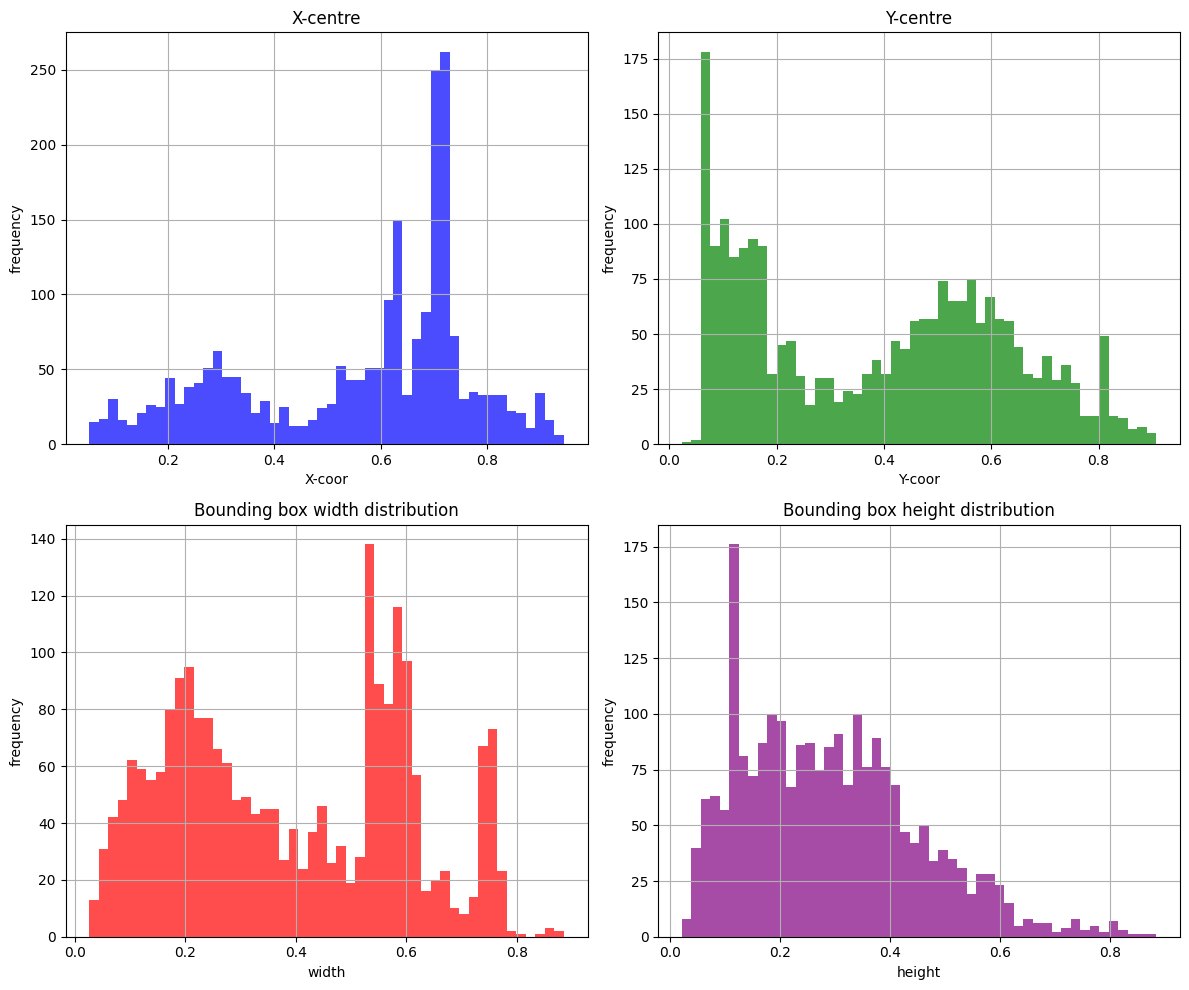

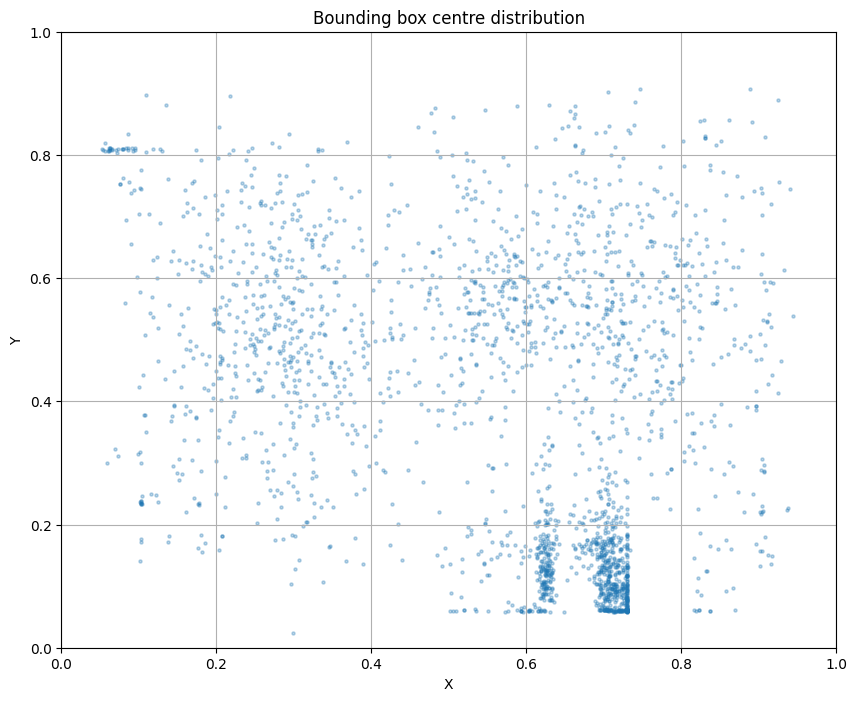

发现 0 个含有问题边界框的文件
未找到有问题的边界框!


In [12]:
analyze_bbox_distribution(extended_dir)

visualize_dataset_bboxes(extended_dir, num_samples=5)

In [13]:
# 第5步：训练YOLOv5模型
print("步骤5: 训练YOLOv5模型")

if disease_classes and os.path.exists(extended_dir):
    print(f"开始训练模型，使用扩展数据集路径: {extended_dir}")
    
    # 设置训练参数
    BATCH_SIZE = 8
    EPOCHS = 50
    IMAGE_SIZE = 640
    MODEL_TYPE = 's' 
    
    %cd /kaggle/working/yolov5
    !python train.py --img {IMAGE_SIZE} --batch {BATCH_SIZE} --epochs {EPOCHS} \
                     --data {extended_dir}/data.yaml \
                     --cfg models/yolov5{MODEL_TYPE}.yaml \
                     --weights yolov5{MODEL_TYPE}.pt \
                     --name chest_xray_pc1_model \
                     --cache
else:
    print("数据集准备不完整，无法开始训练")

步骤5: 训练YOLOv5模型
开始训练模型，使用扩展数据集路径: /kaggle/working/NIH_ChestXray_YOLO/extended
/kaggle/working/yolov5
2025-03-18 04:33:27.040902: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-18 04:33:27.247741: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-18 04:33:27.308306: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout